### Fractal choice
Selected from the lab sheet's pre-approved textbook list (Chapter 6.6, "Program of the Chapter: Chaos Game for the Fern"). Chosen because it uses fundamentally different mathematics from the Mandelbrot/Julia sets covered earlier (random iterated function systems, not complex-plane divergence), satisfying the requirement that Part 3's fractal not be too similar to those already covered.

Total points plotted: 7,500,000


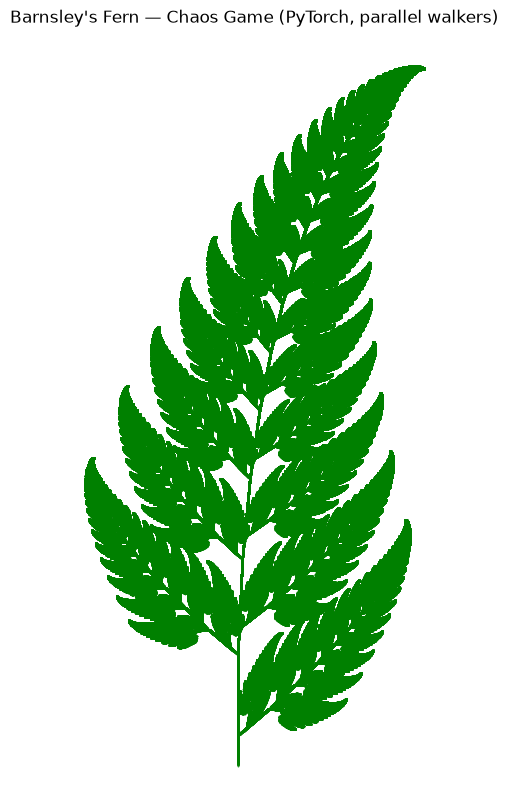

In [ ]:
# Fractal
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Classic Barnsley fern IFS coefficients (Search from https://www.fractal.garden/barnsley-fern)
# x' = a*x + b*y + e ,  y' = c*x + d*y + f ,  with probability p
coeffs = torch.tensor([
    [ 0.00,  0.00,  0.00,  0.16, 0.00, 0.00, 0.01],  # stem
    [ 0.85,  0.04, -0.04,  0.85, 0.00, 1.60, 0.85],  # successively smaller leaflets
    [ 0.20, -0.26,  0.23,  0.22, 0.00, 1.60, 0.07],  # largest left leaflet
    [-0.15,  0.28,  0.26,  0.24, 0.00, 0.44, 0.07],  # largest right leaflet
], device=device)

a, b, c, d, e, f, p = coeffs.T
cum_p = torch.cumsum(p, dim=0)

B = 50000          # parallel walkers
warmup = 20
n_steps = 150

x = torch.zeros(B, device=device)
y = torch.zeros(B, device=device)
xs_all, ys_all = [], []

for step in range(warmup + n_steps):
    r = torch.rand(B, device=device)
    idx = torch.bucketize(r, cum_p)          # vectorized map selection — no per-walker loop
    ai, bi, ci, di, ei, fi = a[idx], b[idx], c[idx], d[idx], e[idx], f[idx] #every walker gets its own transformation coefficients
    x, y = ai * x + bi * y + ei, ci * x + di * y + fi #actual batched affine transformation
    if step >= warmup:
        xs_all.append(x.clone())
        ys_all.append(y.clone())

xs = torch.cat(xs_all).cpu().numpy()
ys = torch.cat(ys_all).cpu().numpy()
print(f"Total points plotted: {len(xs):,}")

plt.figure(figsize=(6, 10))
plt.scatter(xs, ys, s=0.1, color='green')
plt.axis('equal'); plt.axis('off')
plt.title("Barnsley's Fern — Chaos Game (PyTorch, parallel walkers)")
plt.savefig('fern.png', dpi=150)
plt.show()

### Implementation approach
**Not directly AI-generated — designed with AI-assisted discussion of the parallelisation strategy.** 
**Prompt:** "I am planning to generate a fractals and the title is from the textbook Fractals from the Classroom, Chapter 6.6 - Program of the Chapter: Chaos Game for the Fern. I was thinking about parallelism in generating this fractal rather than those traditional method which generating one by one, require heavy computational. Can you give me some idea about this?"

**Result:** Worked. The core idea (run many independent "chaos game" walkers simultaneously as a single batched tensor, instead of one walker run for many sequential steps) was developed through discussion of how to make the classic single-point chaos game algorithm GPU-parallel. Implemented using the standard Barnsley fern IFS coefficients (4 affine maps with fixed probabilities: 0.01 stem, 0.85 main leaflets, 0.07 + 0.07 large left/right leaflets).

Key implementation details I'm responsible for and can explain:
- `torch.bucketize(r, cum_p)` vectorizes the random selection of which of the 4 affine maps each of the 50,000 parallel walkers uses at each step — replacing what would otherwise be a per-walker conditional check.
- The affine transform itself (`x, y = ai*x + bi*y + ei, ci*x + di*y + fi`) is applied to all 50,000 walkers' current positions in a single tensor operation per iteration step.
- A 20-step warmup period is discarded before collecting points, to let walkers settle onto the attractor before recording their trajectory.

Estimated box-counting dimension: 1.814


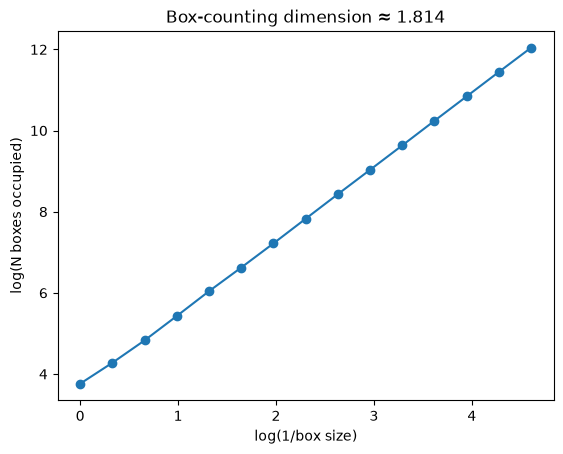

In [ ]:
# Substantial analysis
def box_count(xs, ys, box_size):
    bx = np.floor(xs / box_size).astype(int)
    by = np.floor(ys / box_size).astype(int)
    return len(set(zip(bx, by)))

box_sizes = np.logspace(-2, 0, 15)
counts = [box_count(xs, ys, s) for s in box_sizes]

fit = np.polyfit(np.log(1/box_sizes), np.log(counts), 1)
fractal_dim = fit[0]
print(f"Estimated box-counting dimension: {fractal_dim:.3f}")

plt.figure()
plt.plot(np.log(1/box_sizes), np.log(counts), 'o-')
plt.xlabel('log(1/box size)'); plt.ylabel('log(N boxes occupied)')
plt.title(f'Box-counting dimension ≈ {fractal_dim:.3f}')
plt.savefig('fractal_dimension.png', dpi=150)
plt.show()

### Fractal dimension analysis (substantial analysis requirement)
Implemented box-counting dimension estimation: overlaying grids of decreasing box size over the generated point cloud, counting occupied boxes at each scale, and fitting a line to log(N boxes) vs. log(1/box size) — the slope of this line is the estimated fractal dimension.

I estimated the fern's box-counting dimension at 1.814. Unlike the Sierpinski triangle, which has an exact closed-form dimension because its IFS maps are simple similarities, the fern's maps involve non-uniform scaling and shearing, so there's no equally clean formula to check against — box-counting is genuinely the right empirical approach here, and my log-log plot shows a strongly linear fit, which is the real evidence the estimate is reliable.

Total points plotted: 7,500,000


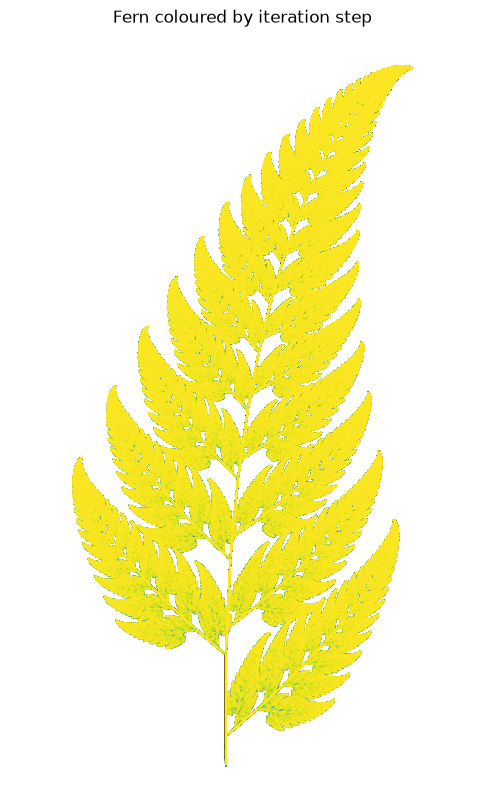

In [ ]:
# Different visualizations and colour output
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Classic Barnsley fern IFS coefficients
# x' = a*x + b*y + e ,  y' = c*x + d*y + f ,  with probability p
coeffs = torch.tensor([
    [ 0.00,  0.00,  0.00,  0.16, 0.00, 0.00, 0.01],  # stem
    [ 0.85,  0.04, -0.04,  0.85, 0.00, 1.60, 0.85],  # successively smaller leaflets
    [ 0.20, -0.26,  0.23,  0.22, 0.00, 1.60, 0.07],  # largest left leaflet
    [-0.15,  0.28,  0.26,  0.24, 0.00, 0.44, 0.07],  # largest right leaflet
], device=device)

a, b, c, d, e, f, p = coeffs.T
cum_p = torch.cumsum(p, dim=0)

B = 50000          # parallel walkers
warmup = 20
n_steps = 150

x = torch.zeros(B, device=device)
y = torch.zeros(B, device=device)
xs_all, ys_all = [], []

for step in range(warmup + n_steps):
    r = torch.rand(B, device=device)
    idx = torch.bucketize(r, cum_p)          # vectorized map selection — no per-walker loop
    ai, bi, ci, di, ei, fi = a[idx], b[idx], c[idx], d[idx], e[idx], f[idx]
    x, y = ai * x + bi * y + ei, ci * x + di * y + fi
    if step >= warmup:
        xs_all.append(x.clone())
        ys_all.append(y.clone())

xs = torch.cat(xs_all).cpu().numpy()
ys = torch.cat(ys_all).cpu().numpy()
print(f"Total points plotted: {len(xs):,}")

iter_ids = np.repeat(np.arange(n_steps), B)
plt.figure(figsize=(6, 10))
plt.scatter(xs, ys, s=0.1, c=iter_ids, cmap='viridis')
plt.axis('equal'); plt.axis('off')
plt.title("Fern coloured by iteration step")
plt.savefig('fern_coloured.png', dpi=150)
plt.show()

### Additional visualisation
Produced a second rendering of the same fern, coloured by iteration step (`cmap='viridis'`) rather than a single flat colour, to show the growth order of the attractor — addresses the rubric's suggestion to incorporate different visualisations/colours as part of the substantial analysis requirement.